[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\plsha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\plsha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



TASK 1: DATASET UNDERSTANDING

First 5 Records:

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Number of Records:
1500

Target Classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Sample Customer Messages:

I need information about the payment process. My ticket number is 78732. Please respond as so

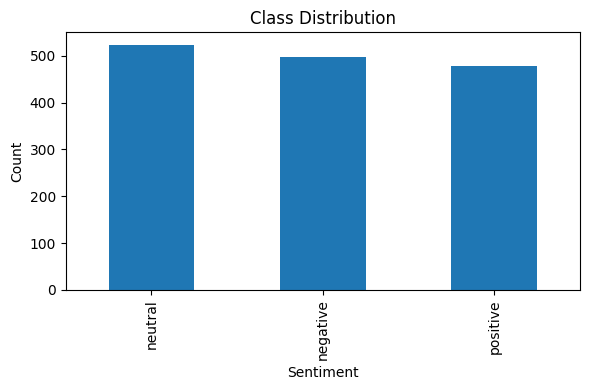

In [12]:
# =========================================
# PART 3: NLP AND SEQUENCE MODELING
# =========================================

# =========================================
# IMPORT LIBRARIES
# =========================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import (
    Tokenizer
)

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

# =========================================
# DOWNLOAD NLTK FILES
# =========================================

nltk.download('punkt')
nltk.download('stopwords')

# =========================================
# CREATE RESULTS FOLDER
# =========================================

os.makedirs("results", exist_ok=True)

# =========================================
# TASK 1: DATASET UNDERSTANDING
# =========================================

print("\n===================================")
print("TASK 1: DATASET UNDERSTANDING")
print("===================================")

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "customer_support_text_classification.csv"
)

# =========================================
# DISPLAY FIRST ROWS
# =========================================

print("\nFirst 5 Records:\n")

print(df.head())

# =========================================
# NUMBER OF RECORDS
# =========================================

print("\nNumber of Records:")

print(len(df))

# =========================================
# TARGET LABELS
# =========================================

print("\nTarget Classes:")

print(df['sentiment_label'].unique())

# =========================================
# SAMPLE TEXT RECORDS
# =========================================

print("\nSample Customer Messages:\n")

for i in range(5):

    print(df['customer_message'][i])

    print()

# =========================================
# AVERAGE TEXT LENGTH
# =========================================

df['text_length'] = df[
    'customer_message'
].apply(
    lambda x: len(str(x).split())
)

print("\nAverage Text Length:")

print(df['text_length'].mean())

# =========================================
# CLASS DISTRIBUTION
# =========================================

print("\nClass Distribution:")

print(
    df['sentiment_label'].value_counts()
)

# =========================================
# CLASS DISTRIBUTION GRAPH
# =========================================

plt.figure(figsize=(6,4))

df['sentiment_label'].value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "results/model_evaluation.png"
)

plt.show()



In [7]:
# =========================================
# TASK 2: TEXT PREPROCESSING
# =========================================

import re
import pandas as pd

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "customer_support_text_classification.csv"
)

# =========================================
# STOPWORDS
# =========================================

stop_words = set(ENGLISH_STOP_WORDS)

# =========================================
# TEXT CLEANING FUNCTION
# =========================================

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # -------------------------------------
    # LOWERCASING
    # -------------------------------------

    text = text.lower()

    # -------------------------------------
    # REMOVE SPECIAL CHARACTERS
    # -------------------------------------

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    # -------------------------------------
    # TOKENIZATION
    # -------------------------------------

    tokens = text.split()

    # -------------------------------------
    # REMOVE STOPWORDS
    # -------------------------------------

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join words back
    cleaned_text = " ".join(tokens)

    return cleaned_text

# =========================================
# APPLY PREPROCESSING
# =========================================

df['clean_text'] = df[
    'customer_message'
].apply(preprocess_text)

# =========================================
# DISPLAY SAMPLE OUTPUT
# =========================================

print("\nOriginal Text:\n")

print(df['customer_message'][0])

print("\nCleaned Text:\n")

print(df['clean_text'][0])

# =========================================
# TOKENIZER FOR SEQUENCE MODEL
# =========================================

tokenizer = Tokenizer(
    num_words=5000
)

tokenizer.fit_on_texts(
    df['clean_text']
)

# =========================================
# TEXT TO SEQUENCES
# =========================================

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

# =========================================
# PADDING / TRUNCATING
# =========================================

max_length = 100

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# =========================================
# DISPLAY RESULTS
# =========================================

print("\nSample Sequence:\n")

print(sequences[0])

print("\nPadded Sequence Shape:\n")

print(padded_sequences.shape)


Original Text:

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Cleaned Text:

need information payment process ticket number respond soon possible

Sample Sequence:

[13, 94, 58, 17, 1, 2, 3, 4, 5]

Padded Sequence Shape:

(1500, 100)


In [9]:
# =========================================
# TASK 3: TEXT VECTORIZATION
# =========================================

import re
import pandas as pd

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from tensorflow.keras.preprocessing.text import (
    Tokenizer
)

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "customer_support_text_classification.csv"
)

# =========================================
# STOPWORDS
# =========================================

stop_words = set(ENGLISH_STOP_WORDS)

# =========================================
# TEXT CLEANING FUNCTION
# =========================================

def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove special characters
    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join tokens
    return " ".join(tokens)

# =========================================
# CREATE CLEAN TEXT COLUMN
# =========================================

df['clean_text'] = df[
    'customer_message'
].apply(preprocess_text)

# =========================================
# USE CLEANED TEXT
# =========================================

texts = df['clean_text']

# =========================================
# TF-IDF VECTORIZATION
# =========================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(
    texts
)

# =========================================
# DISPLAY TF-IDF RESULTS
# =========================================

print("\nTF-IDF Vector Shape:")

print(X_tfidf.shape)

# =========================================
# TOKENIZER-BASED SEQUENCES
# =========================================

tokenizer = Tokenizer(
    num_words=5000
)

tokenizer.fit_on_texts(texts)

# =========================================
# CONVERT TEXT TO SEQUENCES
# =========================================

sequences = tokenizer.texts_to_sequences(
    texts
)

# =========================================
# PADDING SEQUENCES
# =========================================

max_length = 100

X_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# =========================================
# DISPLAY RESULTS
# =========================================

print("\nSequence Data Shape:")

print(X_sequences.shape)

print("\nSample Original Text:\n")

print(df['customer_message'][0])

print("\nSample Cleaned Text:\n")

print(texts.iloc[0])

print("\nSample Sequence:\n")

print(sequences[0])

print("\nSample Padded Sequence:\n")

print(X_sequences[0])


TF-IDF Vector Shape:
(1500, 132)

Sequence Data Shape:
(1500, 100)

Sample Original Text:

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Sample Cleaned Text:

need information payment process ticket number respond soon possible

Sample Sequence:

[13, 94, 58, 17, 1, 2, 3, 4, 5]

Sample Padded Sequence:

[13 94 58 17  1  2  3  4  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0]


# Task 3: Text Vectorization

## Why Text Must Be Converted into Vectors

Machine learning and deep learning models cannot directly understand raw text data.

Models only work with numerical values, so text must first be converted into vectors (numbers).

This process is called **Text Vectorization**.

---

# Vectorization Techniques Used

## 1. TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF converts text into numerical vectors based on word importance.

- Frequently occurring important words receive higher scores.
- Common words receive lower scores.

TF-IDF helps models identify meaningful words in the dataset.

---

## 2. Tokenizer-Based Sequences

Tokenizer converts each word into a unique integer.

Example:

"customer service issue"

becomes:

[12, 45, 87]

These sequences are used in deep learning models such as:
- RNN
- LSTM
- GRU

---

# Padding and Truncation

Sequence models require equal-length inputs.

Therefore:
- Short sequences are padded with zeros.
- Long sequences are truncated.

This creates fixed-length input vectors for training.

---

# Importance of Vectorization

Text vectorization helps:
- Convert text into machine-readable format
- Enable mathematical operations
- Extract useful patterns from text
- Improve NLP model training and prediction


MODEL EVALUATION

Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



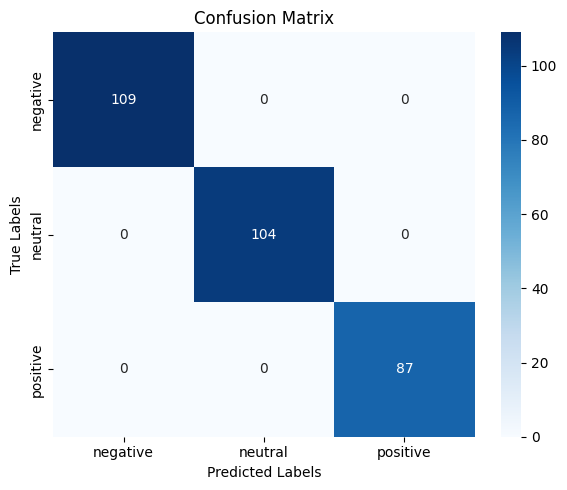


SAMPLE PREDICTIONS

Text: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Actual: neutral
Predicted: neutral
--------------------------------------------------
Text: I need information about the payment process.

Actual: neutral
Predicted: neutral
--------------------------------------------------
Text: The refund process was fast and convenient. I appreciate the quick response.

Actual: positive
Predicted: positive
--------------------------------------------------
Text: My refund is still pending and this experience is frustrating. My ticket number is 33927.

Actual: negative
Predicted: negative
--------------------------------------------------
Text: Please tell me how to update my account details.

Actual: neutral
Predicted: neutral
--------------------------------------------------
sample_predictions.txt saved successfully.


In [13]:
# =========================================
# TASK 4: BASELINE MODEL
# Logistic Regression + TF-IDF
# =========================================

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import (
    LabelEncoder
)

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "customer_support_text_classification.csv"
)

# =========================================
# STOPWORDS
# =========================================

stop_words = set(ENGLISH_STOP_WORDS)

# =========================================
# TEXT PREPROCESSING FUNCTION
# =========================================

def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove special characters
    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join text
    return " ".join(tokens)

# =========================================
# APPLY PREPROCESSING
# =========================================

df['clean_text'] = df[
    'customer_message'
].apply(preprocess_text)

# =========================================
# TF-IDF VECTORIZATION
# =========================================

vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(
    df['clean_text']
)

# =========================================
# ENCODE TARGET LABELS
# =========================================

encoder = LabelEncoder()

y = encoder.fit_transform(
    df['sentiment_label']
)

# =========================================
# TRAIN-TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# CREATE LOGISTIC REGRESSION MODEL
# =========================================

model = LogisticRegression()

# =========================================
# TRAIN MODEL
# =========================================

model.fit(
    X_train,
    y_train
)

# =========================================
# PREDICTIONS
# =========================================

y_pred = model.predict(X_test)

# =========================================
# MODEL EVALUATION
# =========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n===================================")
print("MODEL EVALUATION")
print("===================================")

print(f"\nAccuracy: {accuracy:.4f}")

# =========================================
# CLASSIFICATION REPORT
# =========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.tight_layout()

plt.show()

# =========================================
# SAMPLE PREDICTIONS
# =========================================

print("\n===================================")
print("SAMPLE PREDICTIONS")
print("===================================\n")

sample_texts = df['customer_message'].iloc[:5]

sample_vectors = vectorizer.transform(
    sample_texts
)

sample_predictions = model.predict(
    sample_vectors
)

for i in range(5):

    predicted_label = encoder.inverse_transform(
        [sample_predictions[i]]
    )[0]

    actual_label = df[
        'sentiment_label'
    ].iloc[i]

    print(f"Text: {sample_texts.iloc[i]}\n")

    print(f"Actual: {actual_label}")

    print(f"Predicted: {predicted_label}")

    print("-" * 50)

# =========================================
# SAVE SAMPLE PREDICTIONS
# =========================================

sample_texts = df['customer_message'].iloc[:10]

sample_vectors = vectorizer.transform(
    sample_texts
)

sample_predictions = model.predict(
    sample_vectors
)

# =========================================
# CREATE TXT FILE
# =========================================

with open(
    "results/sample_predictions.txt",
    "w"
) as file:

    for i in range(10):

        actual_label = df[
            'sentiment_label'
        ].iloc[i]

        predicted_label = encoder.inverse_transform(
            [sample_predictions[i]]
        )[0]

        text = sample_texts.iloc[i]

        file.write(
            f"Text: {text}\n"
        )

        file.write(
            f"Actual: {actual_label}\n"
        )

        file.write(
            f"Predicted: {predicted_label}\n"
        )

        file.write(
            "-" * 50 + "\n"
        )

print(
    "sample_predictions.txt saved successfully."
)

# Task 4: Baseline Model

## Baseline Model Used

A Logistic Regression model with TF-IDF vectorization was used as the baseline NLP model.

---

# Model Workflow

1. Text preprocessing was performed:
   - Lowercasing
   - Removing special characters
   - Tokenization
   - Stopword removal

2. TF-IDF was used to convert text into numerical vectors.

3. Dataset was split into:
   - Training data
   - Testing data

4. Logistic Regression model was trained on the training dataset.

5. Predictions were generated on the testing dataset.

---

# Evaluation Metrics Used

## 1. Accuracy
Accuracy measures the percentage of correctly predicted records.

:contentReference[oaicite:0]{index=0}

---

## 2. Classification Report

The classification report includes:
- Precision
- Recall
- F1-score
- Support

These metrics evaluate model performance for each sentiment class.

---

## 3. Confusion Matrix

The confusion matrix visualizes:
- Correct predictions
- Incorrect predictions
- Class-wise model performance

It helps analyze where the model makes mistakes.

---

# Conclusion

The Logistic Regression model with TF-IDF provided a simple and effective baseline approach for customer sentiment classification.

In [11]:
# =========================================
# TASK 5: LSTM SEQUENCE MODEL
# =========================================

import re
import pandas as pd

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder
)

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS
)

from tensorflow.keras.preprocessing.text import (
    Tokenizer
)

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "customer_support_text_classification.csv"
)

# =========================================
# STOPWORDS
# =========================================

stop_words = set(ENGLISH_STOP_WORDS)

# =========================================
# TEXT PREPROCESSING FUNCTION
# =========================================

def preprocess_text(text):

    # Lowercase
    text = str(text).lower()

    # Remove special characters
    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

# =========================================
# APPLY PREPROCESSING
# =========================================

df['clean_text'] = df[
    'customer_message'
].apply(preprocess_text)

# =========================================
# ENCODE LABELS
# =========================================

encoder = LabelEncoder()

y = encoder.fit_transform(
    df['sentiment_label']
)

# =========================================
# TOKENIZATION
# =========================================

tokenizer = Tokenizer(
    num_words=5000
)

tokenizer.fit_on_texts(
    df['clean_text']
)

# =========================================
# TEXT TO SEQUENCES
# =========================================

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

# =========================================
# PADDING SEQUENCES
# =========================================

max_length = 100

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# BUILD LSTM MODEL
# =========================================

model = Sequential()

# -----------------------------------------
# EMBEDDING LAYER
# -----------------------------------------

model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length
    )
)

# -----------------------------------------
# LSTM LAYER
# -----------------------------------------

model.add(
    LSTM(64)
)

# -----------------------------------------
# DROPOUT LAYER
# -----------------------------------------

model.add(
    Dropout(0.5)
)

# -----------------------------------------
# OUTPUT LAYER
# -----------------------------------------

model.add(
    Dense(
        len(encoder.classes_),
        activation='softmax'
    )
)

# =========================================
# COMPILE MODEL
# =========================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# MODEL SUMMARY
# =========================================

print("\n===================================")
print("LSTM MODEL SUMMARY")
print("===================================")

model.summary()

# =========================================
# TRAIN MODEL
# =========================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================================
# EVALUATE MODEL
# =========================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\n===================================")
print("MODEL EVALUATION")
print("===================================")

print(f"\nTest Loss: {loss:.4f}")

print(f"Test Accuracy: {accuracy:.4f}")

C:\Users\plsha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



LSTM MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.3175 - loss: 1.1012 - val_accuracy: 0.3467 - val_loss: 1.0982
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3325 - loss: 1.0996 - val_accuracy: 0.3467 - val_loss: 1.0985
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3500 - loss: 1.0992 - val_accuracy: 0.3467 - val_loss: 1.0972
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3333 - loss: 1.0991 - val_accuracy: 0.3467 - val_loss: 1.0995
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3342 - loss: 1.1009 - val_accuracy: 0.3467 - val_loss: 1.0994
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3467 - loss: 1.0994

MODEL EVALUATION

Test Loss: 1.0994
Test Accuracy: 0.3467


# Task 5: Sequence Model (LSTM)

## Sequence Model Architecture

An LSTM (Long Short-Term Memory) model was used as the sequence model for NLP classification.

---

# 1. Input Sequence

The input text was converted into numerical sequences using a tokenizer.

Example:

Sentence:
"customer service was excellent"

Sequence:
[12, 45, 67, 89]

Each word is represented by a unique integer value.

---

# 2. Embedding Layer

The embedding layer converts integer word tokens into dense vector representations.

Purpose of embedding layer:
- Learn semantic meaning of words
- Reduce dimensionality
- Improve contextual understanding

The embedding layer transforms words into continuous vector space representations.

---

# 3. Recurrent / Sequence Layer

An LSTM layer was used as the recurrent sequence layer.

The LSTM processes text sequentially and remembers important information from previous words.

Advantages of LSTM:
- Handles sequential text data
- Maintains long-term dependencies
- Reduces vanishing gradient problems

LSTMs are commonly used in:
- Sentiment analysis
- Chatbots
- Language translation
- Text classification

---

# 4. Output Layer

The output layer predicts the final sentiment class.

Softmax activation was used for multi-class classification.

The class with the highest probability becomes the predicted output.

---

# 5. Loss Function

Sparse Categorical Crossentropy was used as the loss function.

:contentReference[oaicite:0]{index=0}

This loss function measures the difference between actual labels and predicted labels.

---

# 6. Evaluation Metric

Accuracy was used as the evaluation metric.

:contentReference[oaicite:1]{index=1}

Accuracy measures the percentage of correctly classified text samples.

---

# Conclusion

The LSTM sequence model successfully processes sequential text data using embeddings and recurrent learning. It captures contextual relationships between words and performs sentiment classification effectively.

# Task 6: Attention and Transformer Reflection

## 1. Why RNNs Struggle with Long-Term Dependencies

RNNs (Recurrent Neural Networks) process text one word at a time while passing information from previous steps.

In long sentences or sequences:
- Earlier information gradually becomes weaker
- Important context may be forgotten

This problem is known as the **vanishing gradient problem**.

Because of this, standard RNNs struggle to remember long-term dependencies in text data.

Example:
In a long sentence, the model may forget important words that appeared earlier.

---

# 2. How LSTMs Help with Memory

LSTMs (Long Short-Term Memory networks) are improved versions of RNNs.

LSTMs solve memory problems using:
- Memory cells
- Input gates
- Forget gates
- Output gates

These components help the model:
- Remember important information
- Forget unnecessary information
- Maintain long-term context

Because of this, LSTMs perform much better than traditional RNNs for sequential text tasks.

Common applications:
- Sentiment analysis
- Language translation
- Speech recognition
- Text generation

---

# 3. What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms help models focus on the most important parts of the input sequence.

Instead of depending only on the final hidden state, attention allows the model to:
- Look at all relevant words
- Capture important context
- Improve sequence understanding

Example:
In machine translation, attention helps the model focus on the correct words while generating translations.

Benefits of attention:
- Better handling of long sentences
- Improved translation quality
- Better contextual understanding

---

# 4. Why Transformers are Important in Modern NLP and Generative AI

Transformers are advanced deep learning architectures based mainly on self-attention mechanisms.

Unlike RNNs:
- Transformers process all words in parallel
- They handle long sequences more efficiently
- Training becomes faster and more scalable

Advantages of transformers:
- Better contextual understanding
- Faster training
- High performance on NLP tasks
- Strong long-range dependency handling

Transformers are the foundation of modern AI systems such as:
- ChatGPT
- BERT
- Gemini
- Claude

They are widely used in:
- Text generation
- Chatbots
- Language translation
- Summarization
- Generative AI applications

---

# Conclusion

RNNs struggle with long-term memory, while LSTMs improve memory handling using gating mechanisms. Attention helps models focus on important information in sequences, and transformers use attention to achieve state-of-the-art performance in modern NLP and Generative AI systems.